# MELANOMA DETECTION USING CNNs AND VISION TRANSFORMERS

This notebook compares CNN architectures and Vision Transformers for melanoma classification using the HAM10000 dataset.

# 1. Install Required Packages

In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q kagglehub
!pip install -q grad-cam
!pip install -q timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 120.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done



# 2. Import Libraries


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

import timm

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


# 3. Download HAM10000 Dataset

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "kmader/skin-cancer-mnist-ham10000"
)

print("Dataset downloaded successfully")
print(dataset_path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded successfully
/kaggle/input/skin-cancer-mnist-ham10000


# 4. Load Metadata

In [ ]:
metadata_path = os.path.join(
    dataset_path,
    "HAM10000_metadata.csv"
)

df = pd.read_csv(metadata_path)

print(df.head())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


# 5. Define Image Directories

In [ ]:
image_dir_1 = os.path.join(
    dataset_path,
    "HAM10000_images_part_1"
)

image_dir_2 = os.path.join(
    dataset_path,
    "HAM10000_images_part_2"
)

print("Image directories loaded")

Image directories loaded


# 6. Visualize Dataset Distribution

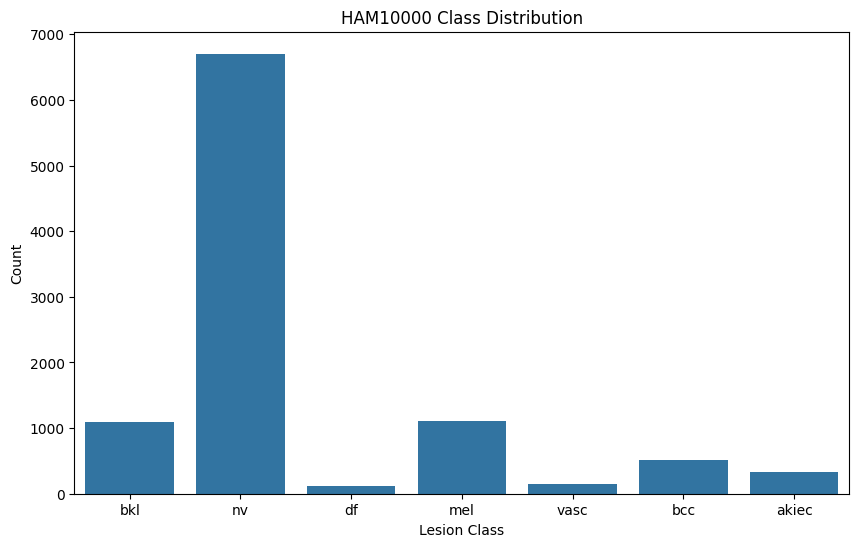

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(x=df['dx'])

plt.title("HAM10000 Class Distribution")

plt.xlabel("Lesion Class")

plt.ylabel("Count")

plt.show()

# 7. Train and Validation Split

In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['dx'],
    random_state=42
)

print("Training Samples:", len(train_df))

print("Validation Samples:", len(val_df))

Training Samples: 8012
Validation Samples: 2003


# 8. Label Encoding

In [ ]:
class_names = sorted(df['dx'].unique())

label_map = {
    label: idx
    for idx, label in enumerate(class_names)
}

inverse_label_map = {
    idx: label
    for label, idx in label_map.items()
}

print(label_map)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


# 9. Image Transformations

In [ ]:
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 10. Custom Dataset Class

In [ ]:
class HAM10000Dataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_id = row['image_id']

        label = row['dx']

        image_path = os.path.join(
            image_dir_1,
            image_id + ".jpg"
        )

        if not os.path.exists(image_path):

            image_path = os.path.join(
                image_dir_2,
                image_id + ".jpg"
            )

        image = Image.open(image_path).convert("RGB")

        if self.transform:

            image = self.transform(image)

        label = label_map[label]

        return image, label

# 11. Create Datasets

In [ ]:
train_dataset = HAM10000Dataset(
    dataframe=train_df,
    transform=transform
)

val_dataset = HAM10000Dataset(
    dataframe=val_df,
    transform=transform
)

print("Datasets created successfully")

Datasets created successfully


# 12. Create DataLoaders

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Dataloaders ready")

Dataloaders ready


# 13. Load ResNet50 Model

In [ ]:
model_resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT
))

num_features = model_resnet.fc.in_features

model_resnet.fc = nn.Linear(num_features, 7)

model_resnet = model_resnet.to(device)

print("ResNet50 loaded successfully")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


ResNet50 loaded successfully


# 14. Define Loss Function and Optimizer

---



In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_resnet.parameters(),
    lr=1e-4
)

# 15. Training Function

In [ ]:
def train_model(model, loader, criterion, optimizer, epochs=5):

    model.train()

    for epoch in range(epochs):

        running_loss = 0.0

        progress_bar = tqdm(loader)

        for images, labels in progress_bar:

            images = images.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(loader)

        print(f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.4f}")

# 16. Train ResNet50 Model

In [ ]:
train_model(
    model_resnet,
    train_loader,
    criterion,
    optimizer,
    epochs=5
)

100%|██████████| 251/251 [03:50<00:00,  1.09it/s]


Epoch 1/5 Loss: 0.7502


100%|██████████| 251/251 [03:01<00:00,  1.39it/s]


Epoch 2/5 Loss: 0.4519


100%|██████████| 251/251 [02:38<00:00,  1.58it/s]


Epoch 3/5 Loss: 0.3371


100%|██████████| 251/251 [02:38<00:00,  1.58it/s]


Epoch 4/5 Loss: 0.2303


100%|██████████| 251/251 [02:38<00:00,  1.58it/s]

Epoch 5/5 Loss: 0.1784


# 17. Evaluation Function

In [ ]:
def evaluate_model(model, loader):

    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)

    macro_f1 = f1_score(
        true_labels,
        predictions,
        average='macro'
    )

    recall = recall_score(
        true_labels,
        predictions,
        average='macro'
    )

    return accuracy, macro_f1, recall, predictions, true_labels

# 18. Evaluate ResNet50

In [ ]:
resnet_accuracy, resnet_f1, resnet_recall, predictions_resnet, labels_resnet = evaluate_model(
    model_resnet,
    val_loader
)

print("ResNet50 Accuracy:", resnet_accuracy)
print("ResNet50 Macro F1:", resnet_f1)
print("ResNet50 Recall:", resnet_recall)

ResNet50 Accuracy: 0.8676984523215178
ResNet50 Macro F1: 0.7748468510372828
ResNet50 Recall: 0.7845089769169373


# 19. Load VGG19 Model

In [ ]:
model_vgg19 = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

num_features = model_vgg19.classifier[6].in_features

model_vgg19.classifier[6] = nn.Linear(
    num_features,
    7
)

model_vgg19 = model_vgg19.to(device)

optimizer_vgg19 = optim.Adam(
    model_vgg19.parameters(),
    lr=1e-4
)

print("VGG19 loaded successfully")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:10<00:00, 56.5MB/s]


VGG19 loaded successfully


# 20. Train VGG19

In [ ]:
train_model(
    model_vgg19,
    train_loader,
    criterion,
    optimizer_vgg19,
    epochs=5
)

100%|██████████| 251/251 [03:42<00:00,  1.13it/s]


Epoch 1/5 Loss: 0.8916


100%|██████████| 251/251 [03:40<00:00,  1.14it/s]


Epoch 2/5 Loss: 0.7389


100%|██████████| 251/251 [03:40<00:00,  1.14it/s]


Epoch 3/5 Loss: 0.6566


100%|██████████| 251/251 [03:40<00:00,  1.14it/s]


Epoch 4/5 Loss: 0.5972


100%|██████████| 251/251 [03:40<00:00,  1.14it/s]

Epoch 5/5 Loss: 0.5456


# 21. Evaluate VGG19

In [ ]:
vgg_accuracy, vgg_f1, vgg_recall, predictions_vgg, labels_vgg = evaluate_model(
    model_vgg19,
    val_loader
)

print("VGG19 Accuracy:", vgg_accuracy)
print("VGG19 Macro F1:", vgg_f1)
print("VGG19 Recall:", vgg_recall)

VGG19 Accuracy: 0.7938092860708936
VGG19 Macro F1: 0.5224058056417857
VGG19 Recall: 0.5031408209930143


# 22. Load Vision Transformer

In [ ]:
model_vit = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,
    num_classes=7
)

model_vit = model_vit.to(device)

optimizer_vit = optim.Adam(
    model_vit.parameters(),
    lr=1e-4
)

print("Vision Transformer loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Vision Transformer loaded successfully


# 23. Train Vision Transformer

In [ ]:
train_model(
    model_vit,
    train_loader,
    criterion,
    optimizer_vit,
    epochs=5
)

100%|██████████| 251/251 [05:47<00:00,  1.38s/it]


Epoch 1/5 Loss: 0.8415


100%|██████████| 251/251 [05:46<00:00,  1.38s/it]


Epoch 2/5 Loss: 0.6072


100%|██████████| 251/251 [05:46<00:00,  1.38s/it]


Epoch 3/5 Loss: 0.5358


100%|██████████| 251/251 [05:45<00:00,  1.38s/it]


Epoch 4/5 Loss: 0.4666


100%|██████████| 251/251 [05:46<00:00,  1.38s/it]

Epoch 5/5 Loss: 0.4234


# 24. Evaluate Vision Transformer

In [ ]:
vit_accuracy, vit_f1, vit_recall, predictions_vit, labels_vit = evaluate_model(
    model_vit,
    val_loader
)

print("ViT Accuracy:", vit_accuracy)
print("ViT Macro F1:", vit_f1)
print("ViT Recall:", vit_recall)

ViT Accuracy: 0.8077883175237144
ViT Macro F1: 0.6932661336078157
ViT Recall: 0.6897348547458321


# 25. ResNet50 Confusion Matrix

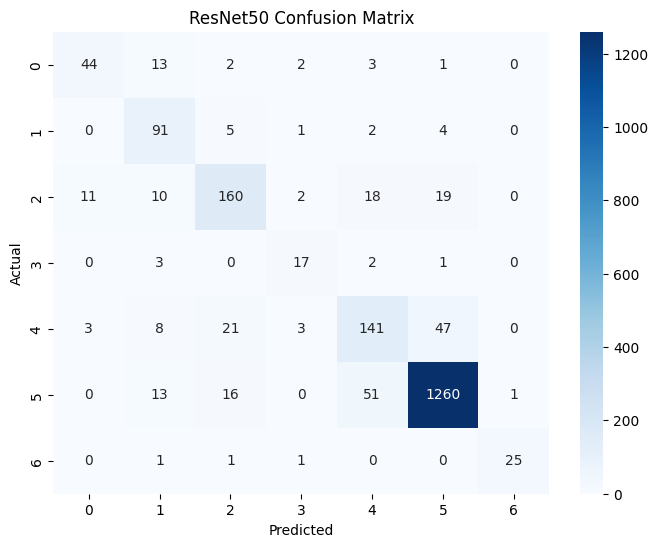

In [ ]:
cm_resnet = confusion_matrix(
    labels_resnet,
    predictions_resnet
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("ResNet50 Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 26. VGG19 Confusion Matrix

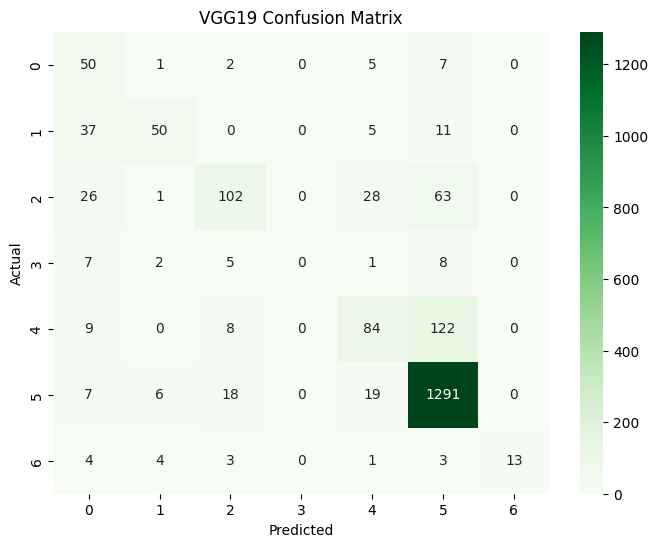

In [ ]:
cm_vgg = confusion_matrix(
    labels_vgg,
    predictions_vgg
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_vgg,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("VGG19 Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 27. Vision Transformer Confusion Matrix

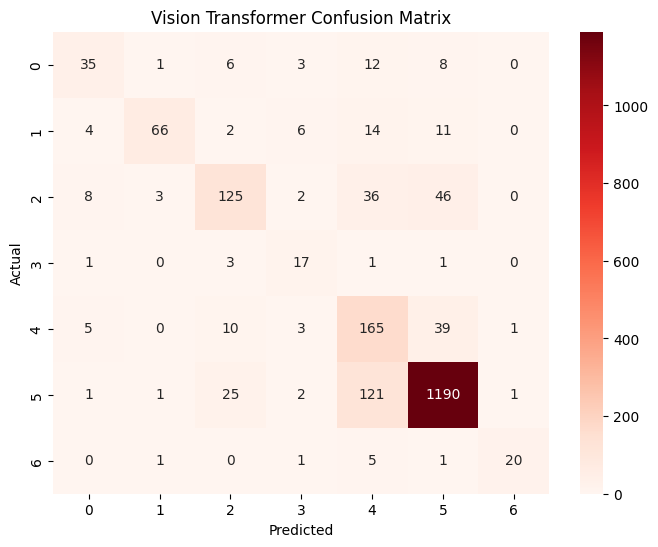

In [ ]:
cm_vit = confusion_matrix(
    labels_vit,
    predictions_vit
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_vit,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("Vision Transformer Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 28. Final Architecture Comparison

In [ ]:
results = pd.DataFrame({

    "Model": [
        "VGG19",
        "ResNet50",
        "Vision Transformer"
    ],

    "Accuracy": [
        vgg_accuracy,
        resnet_accuracy,
        vit_accuracy
    ],

    "Macro_F1": [
        vgg_f1,
        resnet_f1,
        vit_f1
    ],

    "Recall": [
        vgg_recall,
        resnet_recall,
        vit_recall
    ]
})

print(results)

                Model  Accuracy  Macro_F1    Recall
0               VGG19  0.793809  0.522406  0.503141
1            ResNet50  0.867698  0.774847  0.784509
2  Vision Transformer  0.807788  0.693266  0.689735


# 29. Accuracy Comparison Plot

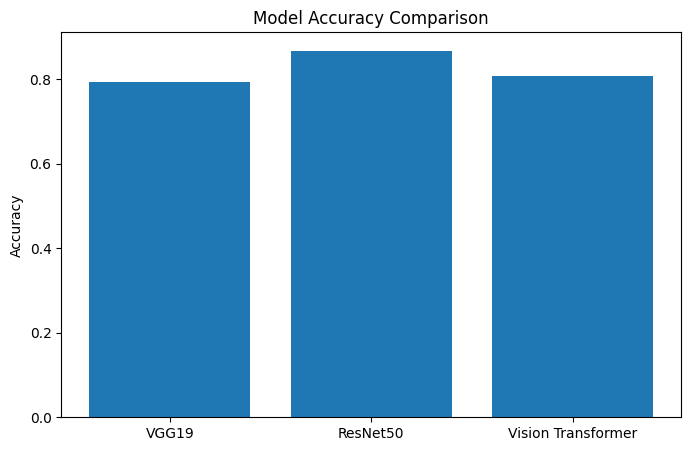

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

# 30. Macro F1 Comparison Plot

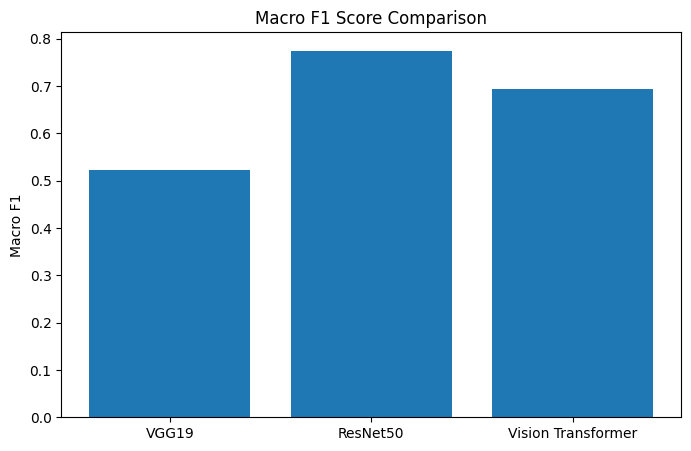

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Macro_F1"]
)

plt.title("Macro F1 Score Comparison")

plt.ylabel("Macro F1")

plt.show()

# 31. Grad-CAM for ResNet50

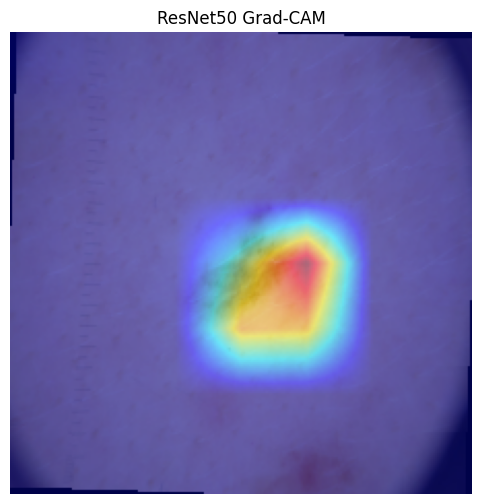

In [ ]:
target_layers = [model_resnet.layer4[-1]]

cam = GradCAM(
    model=model_resnet,
    target_layers=target_layers
)

image, label = val_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

grayscale_cam = cam(input_tensor=input_tensor)[0]

rgb_image = image.permute(1,2,0).numpy()

rgb_image = (rgb_image * 0.229) + 0.485

rgb_image = np.clip(rgb_image, 0, 1)

visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(6,6))

plt.imshow(visualization)

plt.title("ResNet50 Grad-CAM")

plt.axis('off')

plt.show()

# 32. Save Results

In [ ]:
results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Results saved successfully")

Results saved successfully
